In [17]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# UK Housing Prices vs. Mortgage Affordability (2005 – 2025)

## 1. Problem Formulation
This project explores the relationship between UK property values and buyer purchasing power. While the **UK House Price Index (HPI)** tracks market prices, the **Bank of England’s Mortgage Lenders and Administrators Statistics (MLAR)** reveals the underlying financial risk and affordability. The goal is to translate this economic problem into a mathematical counterpart to determine if mortgage metrics serve as indicators for house price shifts.

## 2. Project Objectives
* **Data Integration:** Consolidate monthly price data and quarterly lending statistics to demonstrate skills in merging and validating various data types.
* **Exploratory Data Analysis (EDA):** Use analytical graphs and plots to visualize 20-year trends and identify market cycles.
* **Mathematical Analysis:** Apply statistical methods and hypothesis testing to validate the link between lending constraints and price volatility.

## 3. Data Sources
* **HM Land Registry (UKHPI):** The primary source for housing price trends, providing average prices and sales volumes based on completed sales.
* **Bank of England (MLAR):** An independent data source used for mortgage affordability, covering Loan-to-Value (LTV) and Loan-to-Income (LTI) ratios.

In [2]:
# 1. Setup paths
data_folder = 'data'

# 2. Load the files
house_price_data = pd.read_csv(os.path.join(data_folder, 'ukhpi-united-kingdom-from-2005-01-01-to-2025-12-01.csv'))
mortgage_rate_data = pd.read_csv(os.path.join(data_folder, 'Bank of England  Database.csv'))
employment_data = pd.read_csv(os.path.join(data_folder, 'emp.csv'), skiprows=6)

# 3. Vetting
print("--- DATASET INTEGRITY CHECK ---")
print(f"HPI Rows: {house_price_data.shape[0]} | Rates Rows: {mortgage_rate_data.shape[0]}")
print(f"Date Alignment: {house_price_data['Period'].iloc[-1]} matches BoE Latest Date: {mortgage_rate_data['Date'].iloc[0]}")

--- DATASET INTEGRITY CHECK ---
HPI Rows: 252 | Rates Rows: 252
Date Alignment: 2025-12 matches BoE Latest Date: 31 Dec 25


In [3]:
# 1. Cleaning the Mortgage Rate Data
if 'rate_2yr' not in mortgage_rate_data.columns:
    mortgage_rate_data.rename(columns={
        mortgage_rate_data.columns[0]: 'date',
        mortgage_rate_data.columns[1]: 'rate_2yr',
        mortgage_rate_data.columns[3]: 'rate_5yr'
    }, inplace=True)
    mortgage_rate_data = mortgage_rate_data[['date', 'rate_2yr', 'rate_5yr']]

# 2. Cleaning the House Price Data
if 'avg_house_price' not in house_price_data.columns:
    house_price_data.rename(columns={
        'Period': 'date',
        'Average price All property types': 'avg_house_price'
    }, inplace=True)
    house_price_data = house_price_data[['date', 'avg_house_price']]

# 3. Cleaning the Employment Data
if 'real_earnings' not in employment_data.columns:
    employment_data.rename(columns={
        employment_data.columns[0]: 'date',
        employment_data.columns[4]: 'real_earnings'
    }, inplace=True)
    employment_data = employment_data[['date', 'real_earnings']]

# 4. Standardize all dates to the 1st of the month
for data in [mortgage_rate_data, house_price_data, employment_data]:
    data['date'] = pd.to_datetime(data['date'], errors='coerce', dayfirst=True)
    data.dropna(subset=['date'], inplace=True)
    data['date'] = data['date'].dt.to_period('M').dt.to_timestamp()

house_price_data = house_price_data[['date', 'avg_house_price']]

print("--- FINAL VERIFICATION ---")
print(f"Mortgage: {mortgage_rate_data.columns.tolist()}")
print(f"HPI: {house_price_data.columns.tolist()}")
print(f"Earnings: {employment_data.columns.tolist()}")

--- FINAL VERIFICATION ---
Mortgage: ['date', 'rate_2yr', 'rate_5yr']
HPI: ['date', 'avg_house_price']
Earnings: ['date', 'real_earnings']


/var/folders/75/l9c923tx7lq_kr4c7t01qm5c0000gn/T/ipykernel_78440/2254920748.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['date'] = pd.to_datetime(data['date'], errors='coerce', dayfirst=True)


In [4]:
# --- CONSOLIDATED WORKFLOW: LOAD, CLEAN, & MERGE ---

# 1. Reloading
data_folder = 'data'
hp_raw = pd.read_csv(os.path.join(data_folder, 'ukhpi-united-kingdom-from-2005-01-01-to-2025-12-01.csv'))
mr_raw = pd.read_csv(os.path.join(data_folder, 'Bank of England  Database.csv'))
em_raw = pd.read_csv(os.path.join(data_folder, 'emp.csv'), skiprows=6)

# 2. Cleaning & Renaming
# House Price Data
hp_clean = hp_raw.rename(columns={
    'Period': 'date',
    'Average price All property types': 'avg_house_price'
})[['date', 'avg_house_price']]

# Mortgage Rate Data
mr_clean = mr_raw.rename(columns={
    mr_raw.columns[0]: 'date',
    mr_raw.columns[1]: 'rate_2yr',
    mr_raw.columns[3]: 'rate_5yr'
})[['date', 'rate_2yr', 'rate_5yr']]

# Employment Data
em_clean = em_raw.rename(columns={
    em_raw.columns[0]: 'date',
    em_raw.columns[4]: 'real_earnings'
})[['date', 'real_earnings']]

# 3. Standartize Data
for df in [hp_clean, mr_clean, em_clean]:
    df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)
    df.dropna(subset=['date'], inplace=True)
    df['date'] = df['date'].dt.to_period('M').dt.to_timestamp()

# 4. The Master Merge
# Merge HPI and Mortgage Rates first (monthly)
master_data = pd.merge(hp_clean, mr_clean, on='date', how='inner')

# Merge with Earnings using 'left' to keep all months, then fill the gaps
master_data = pd.merge(master_data, em_clean, on='date', how='left')
master_data['real_earnings'] = master_data['real_earnings'].ffill()

# 5. Final Cleanup
master_data = master_data.sort_values('date').reset_index(drop=True)

print("--- SUCCESS: MONTHLY MASTER DATASET CREATED ---")
print(f"Total Months: {len(master_data)}")
print(master_data.head(15)) # Show first 15 to see the monthly data filling in

--- SUCCESS: MONTHLY MASTER DATASET CREATED ---
Total Months: 252
         date  avg_house_price  rate_2yr  rate_5yr  real_earnings
0  2005-01-01           138759      4.99      5.20          455.0
1  2005-02-01           138626      5.07      5.25          455.0
2  2005-03-01           139763      5.20      5.28          455.0
3  2005-04-01           141751      5.16      5.23          455.0
4  2005-05-01           143273      4.91      5.05          455.0
5  2005-06-01           144410      4.77      4.92          455.0
6  2005-07-01           146269      4.59      4.84          455.0
7  2005-08-01           146864      4.56      4.85          455.0
8  2005-09-01           146635      4.52      4.82          455.0
9  2005-10-01           146342      4.54      4.85          455.0
10 2005-11-01           146777      4.74      4.98          455.0
11 2005-12-01           147580      4.74      5.00          455.0
12 2006-01-01           147360      4.62      4.92          461.0
13 2006-02

/var/folders/75/l9c923tx7lq_kr4c7t01qm5c0000gn/T/ipykernel_78440/1526689054.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)


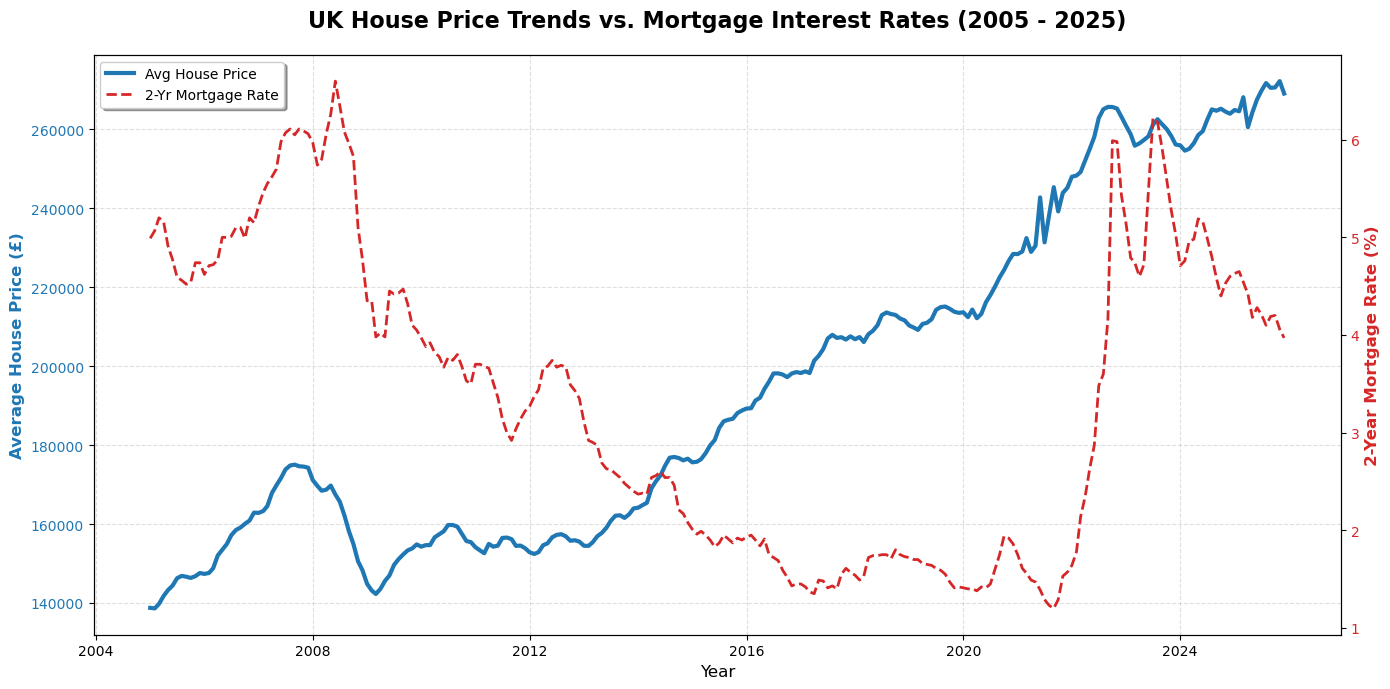

In [5]:
# 1. Setup the figure and the first axis (House Prices)
fig, ax1 = plt.subplots(figsize=(14, 7))

# 2. Plot House Prices (Blue Line)
color_price = 'tab:blue'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Average House Price (£)', color=color_price, fontsize=12, fontweight='bold')
line1 = ax1.plot(master_data['date'], master_data['avg_house_price'], color=color_price, linewidth=3, label='Avg House Price')
ax1.tick_params(axis='y', labelcolor=color_price)
ax1.grid(True, linestyle='--', alpha=0.4)

# 3. Create the second axis (Mortgage Rates)
ax2 = ax1.twinx() 
color_rate = 'tab:red'
ax2.set_ylabel('2-Year Mortgage Rate (%)', color=color_rate, fontsize=12, fontweight='bold')
line2 = ax2.plot(master_data['date'], master_data['rate_2yr'], color=color_rate, linewidth=2, linestyle='--', label='2-Yr Mortgage Rate')
ax2.tick_params(axis='y', labelcolor=color_rate)

# 4. Create a single legend for both lines
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, shadow=True)

# 5. Final Styling
plt.title('UK House Price Trends vs. Mortgage Interest Rates (2005 - 2025)', fontsize=16, fontweight='bold', pad=20)
fig.tight_layout()
plt.show()

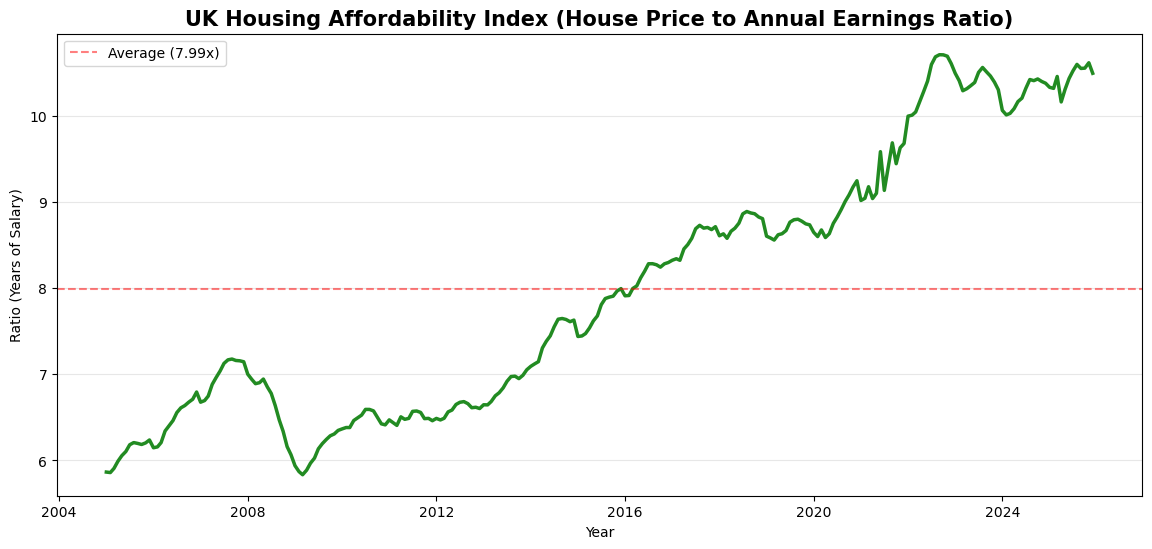

--- AFFORDABILITY KEY STATS ---
Lowest Ratio: 5.83x
Highest Ratio: 10.71x
Current Ratio: 10.50x


In [6]:
# 1. Calculate the Affordability Ratio
# We multiply real_earnings by 52 (because they are usually weekly figures)
master_data['price_to_earnings_ratio'] = master_data['avg_house_price'] / (master_data['real_earnings'] * 52) 

# 2. Create the Affordability Plot
plt.figure(figsize=(14, 6))
plt.plot(master_data['date'], master_data['price_to_earnings_ratio'], color='forestgreen', linewidth=2.5)

# Horizontal line for the average levels
avg_ratio = master_data['price_to_earnings_ratio'].mean()
plt.axhline(avg_ratio, color='red', linestyle='--', alpha=0.5, label=f'Average ({avg_ratio:.2f}x)')

# Styling
plt.title('UK Housing Affordability Index (House Price to Annual Earnings Ratio)', fontsize=15, fontweight='bold')
plt.ylabel('Ratio (Years of Salary)')
plt.xlabel('Year')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Summary Statistics
print("--- AFFORDABILITY KEY STATS ---")
print(f"Lowest Ratio: {master_data['price_to_earnings_ratio'].min():.2f}x")
print(f"Highest Ratio: {master_data['price_to_earnings_ratio'].max():.2f}x")
print(f"Current Ratio: {master_data['price_to_earnings_ratio'].iloc[-1]:.2f}x")

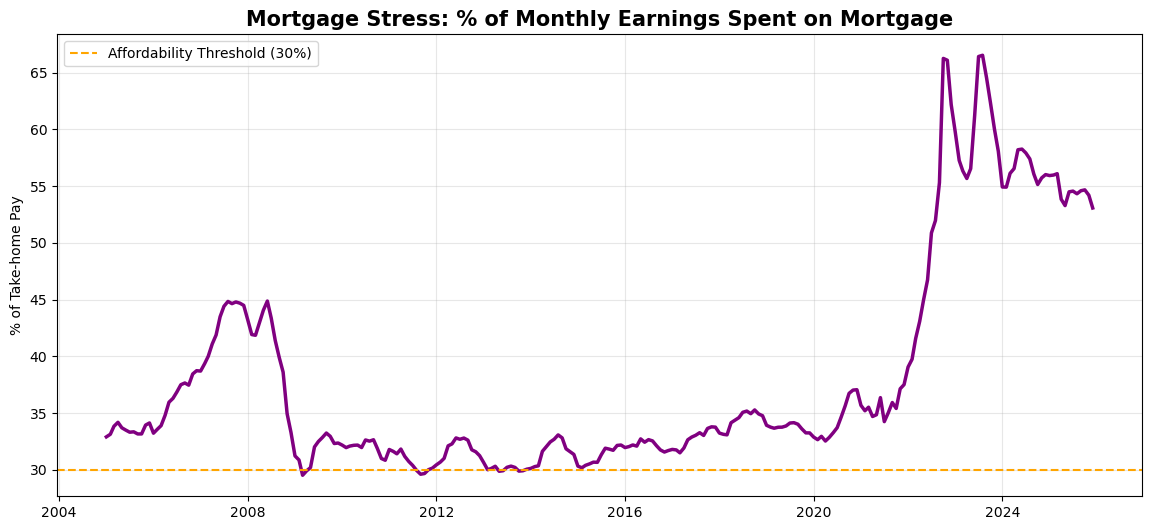

Current Mortgage Stress: 53.1%


In [7]:
# 1. Mortgage Payment Formula
P = master_data['avg_house_price'] * 0.8  # Principal (Loan amount) - 20% deposit, 80% of the house price 
r = (master_data['rate_2yr'] / 100) / 12  # Monthly interest rate
n = 25 * 12                               # Number of months (25 years) - 25-year mortgage term

# Monthly Payment Formula
master_data['monthly_mortgage'] = P * (r * (1 + r)**n) / ((1 + r)**n - 1)

# 2. Monthly Earnings 
master_data['monthly_earnings'] = master_data['real_earnings'] * 4.33  # Weekly * 4.33 weeks per month (52weeks / 12 months = 4.333...)

# 3. Mortgage-to-Income Ratio (%)
master_data['mortgage_stress_ratio'] = (master_data['monthly_mortgage'] / master_data['monthly_earnings']) * 100

# 4. Plot the "Mortgage Stress" over time
plt.figure(figsize=(14, 6))
plt.plot(master_data['date'], master_data['mortgage_stress_ratio'], color='purple', linewidth=2.5)

# Benchmark line (30% is the limit for 'affordability')
plt.axhline(30, color='orange', linestyle='--', label='Affordability Threshold (30%)')

plt.title('Mortgage Stress: % of Monthly Earnings Spent on Mortgage', fontsize=15, fontweight='bold')
plt.ylabel('% of Take-home Pay')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Current Mortgage Stress: {master_data['mortgage_stress_ratio'].iloc[-1]:.1f}%")

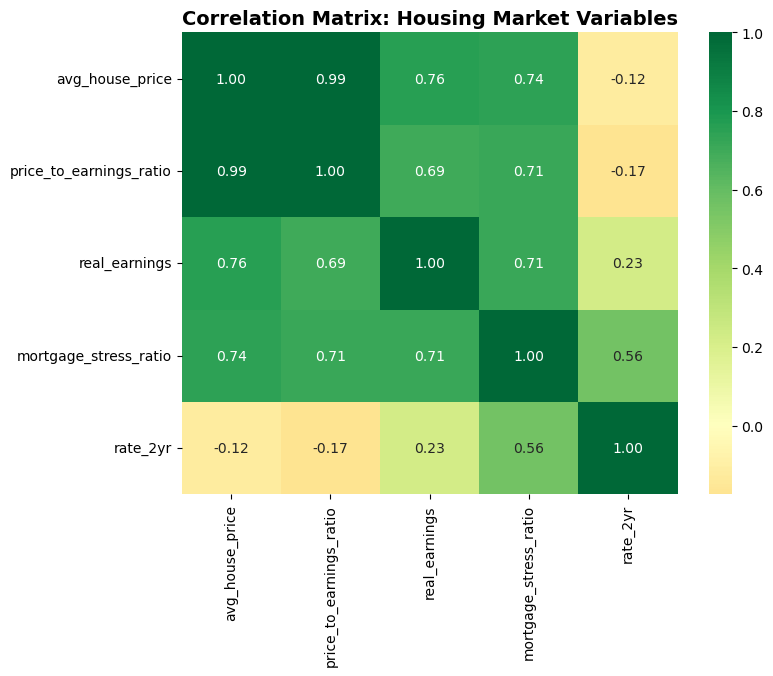

In [8]:
# 1. The key variables for correlation
cols_to_corr = ['avg_house_price', 'price_to_earnings_ratio', 'real_earnings', 'mortgage_stress_ratio', 'rate_2yr']
correlation_matrix = master_data[cols_to_corr].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f')

plt.title('Correlation Matrix: Housing Market Variables', fontsize=14, fontweight='bold')
plt.show()

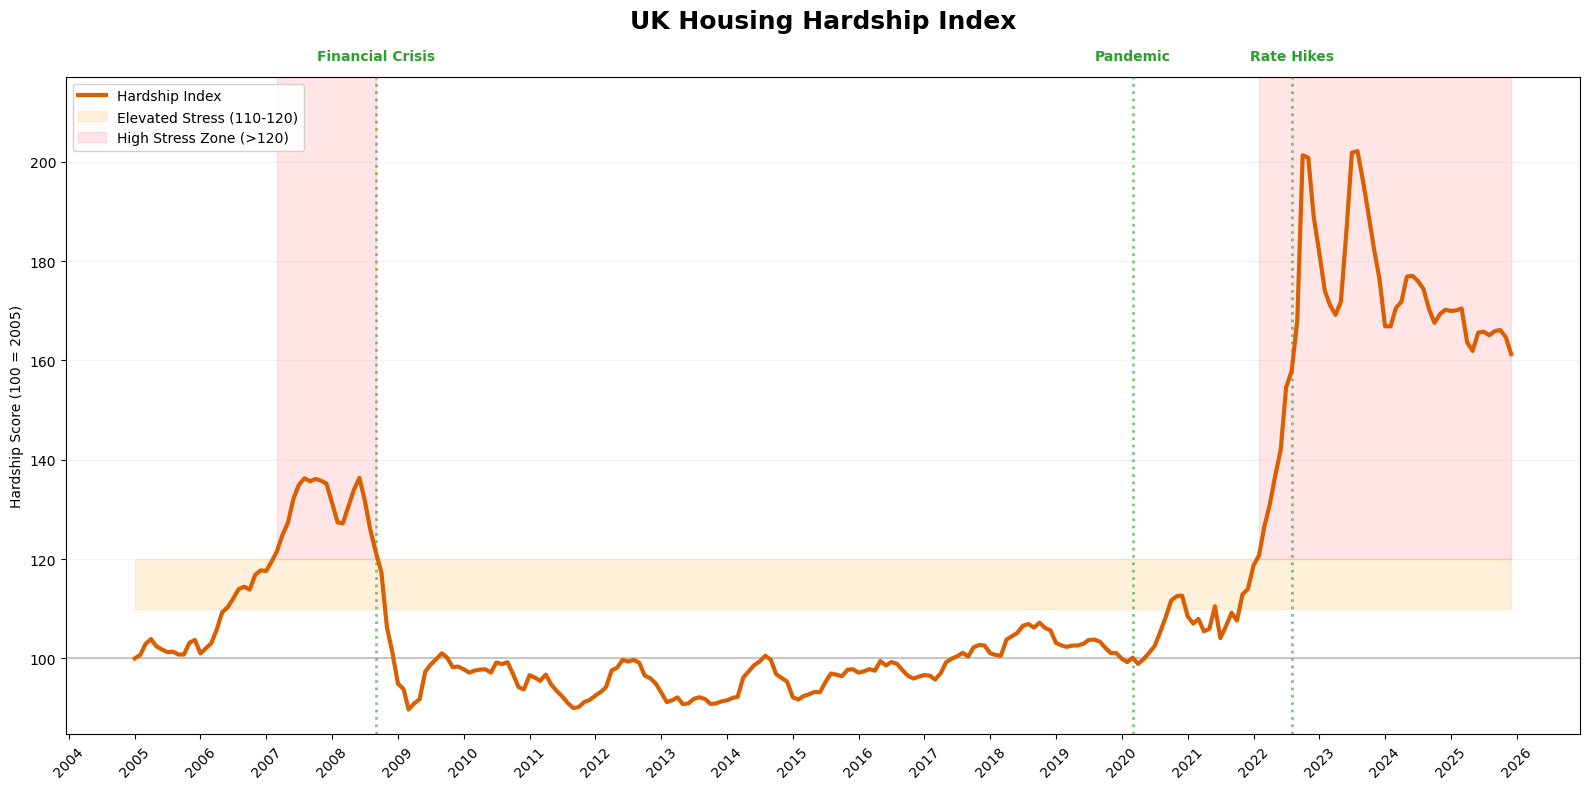

In [35]:
plt.figure(figsize=(16, 8))

# 1. The Core Line
plt.plot(master_data['date'], master_data['hardship_index'], 
         color='#d95f02', linewidth=3, label='Hardship Index', zorder=5)

# 2. Layered Stress Zones
plt.axhline(100, color='black', linestyle='-', alpha=0.2)

plt.fill_between(master_data['date'], 110, 120, 
                 color='orange', alpha=0.15, label='Elevated Stress (110-120)', zorder=2)

plt.fill_between(master_data['date'], 120, master_data['hardship_index'].max() + 20, 
                 where=(master_data['hardship_index'] >= 120), 
                 color='red', alpha=0.1, label='High Stress Zone (>120)', zorder=1)

# 3. Notes
ax = plt.gca()
events = {
    '2008-09-01': 'Financial Crisis',
    '2020-03-01': 'Pandemic',
    '2022-08-01': 'Rate Hikes'
}

for date_str, label in events.items():
    event_date = pd.to_datetime(date_str)
    if event_date > master_data['date'].min():
        # Green dotted vertical line
        plt.axvline(event_date, color='#2ca02c', linestyle=':', alpha=0.6, linewidth=2, zorder=3)
        
        # Horizontal Green Text at the very top (y=1.02)
        plt.text(event_date, 1.02, label, 
                 transform=ax.get_xaxis_transform(), 
                 rotation=0,                  
                 verticalalignment='bottom', 
                 horizontalalignment='center', 
                 fontsize=10, 
                 color='#2ca02c',             
                 fontweight='bold')

# 4. Axis Formatting
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.ylim(master_data['hardship_index'].min() - 5, master_data['hardship_index'].max() + 15)

plt.title('UK Housing Hardship Index', fontsize=18, fontweight='bold', pad=35)
plt.ylabel('Hardship Score (100 = 2005)')
plt.grid(True, axis='y', alpha=0.15)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

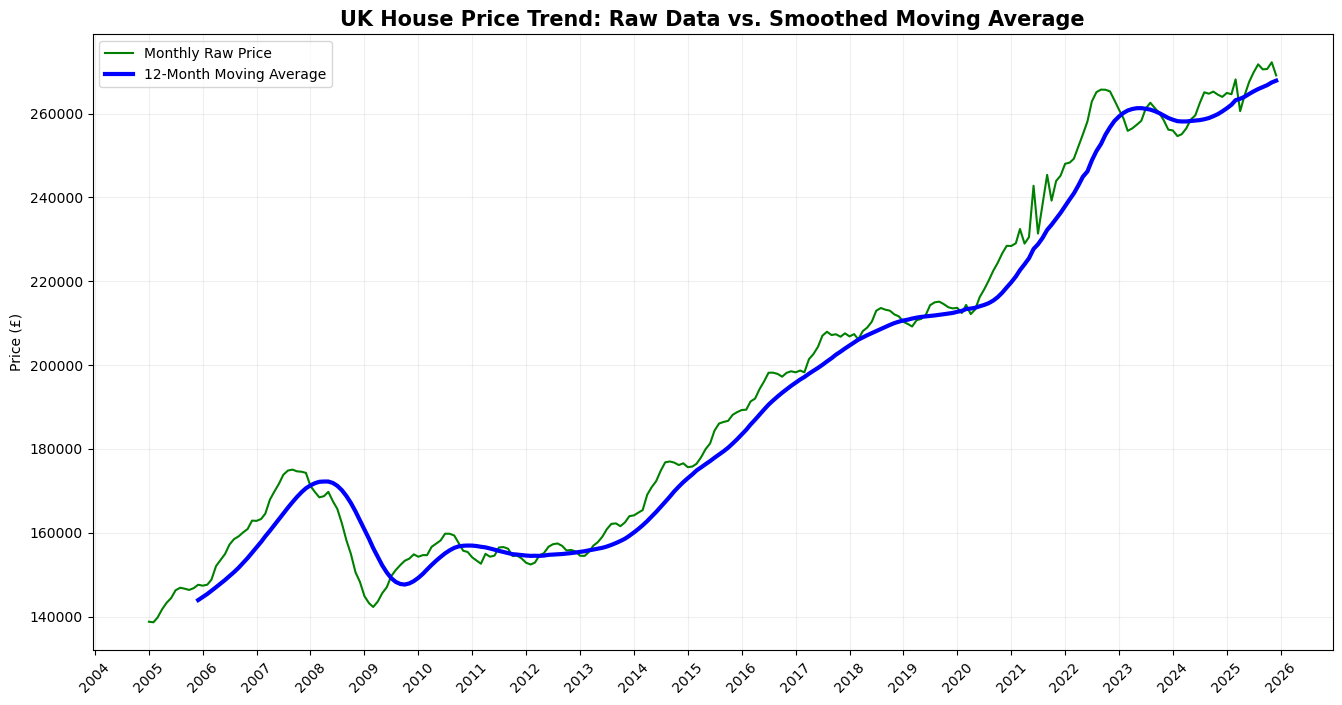

In [43]:
# 1. Calculate the 12-month rolling average
master_data['price_trend_smooth'] = master_data['avg_house_price'].rolling(window=12).mean()

# 2. Plot the Raw Data vs. the Smooth Trend
plt.figure(figsize=(16, 8))
plt.plot(master_data['date'], master_data['avg_house_price'], color='green', alpha=1, label='Monthly Raw Price')
plt.plot(master_data['date'], master_data['price_trend_smooth'], color='blue', linewidth=3, label='12-Month Moving Average')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.title('UK House Price Trend: Raw Data vs. Smoothed Moving Average', fontsize=15, fontweight='bold')
plt.ylabel('Price (£)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()